The first and the most important step of any good data analytics project is to explore and clean the data. So I'll be doing it here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Setup complete.")

Setup complete.


Loading just one month of data

In [2]:
URL_PRICE = "https://storage.data.gov.my/pricecatcher/pricecatcher_2026-04.parquet"
URL_ITEM = "https://storage.data.gov.my/pricecatcher/lookup_item.parquet"
URL_PREMISE = "https://storage.data.gov.my/pricecatcher/lookup_premise.parquet"

price = pd.read_parquet(URL_PRICE)
item = pd.read_parquet(URL_ITEM)
premise = pd.read_parquet(URL_PREMISE)

print("Price shape:", price.shape)
print("Item shape:", item.shape)
print("Premise shape:", premise.shape)

Price shape: (1745608, 4)
Item shape: (757, 5)
Premise shape: (3860, 6)


Inspect the raw tables

In [3]:
print("PRICE COLUMNS")
print(price.columns.tolist())

print("\nITEM COLUMNS")
print(item.columns.tolist())

print("\nPREMISE COLUMNS")
print(premise.columns.tolist())

PRICE COLUMNS
['date', 'premise_code', 'item_code', 'price']

ITEM COLUMNS
['item_code', 'item', 'unit', 'item_group', 'item_category']

PREMISE COLUMNS
['premise_code', 'premise', 'address', 'premise_type', 'state', 'district']


In [4]:
price.head()

,date,premise_code,item_code,price
0,2026-04-01,2,1,10.8
1,2026-04-01,2,47,10.0
2,2026-04-01,2,55,8.0
3,2026-04-01,2,70,24.0
4,2026-04-01,2,88,10.0


In [5]:
item.head()

,item_code,item,unit,item_group,item_category
0,-1,NaN,NaN,NaN,NaN
1,1,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
2,2,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM
3,3,AYAM HIDUP,1kg,BARANGAN SEGAR,AYAM
4,9,DAGING KAMBING BEBIRI IMPORT BERTULANG (MUTTON...,1kg,BARANGAN SEGAR,DAGING


In [6]:
premise.head()

,premise_code,premise,address,premise_type,state,district
0,-1.0,NaN,",",NaN,NaN,NaN
1,2.0,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,3.0,JUSCO AYER KEROH,"LOT 4991,MUKIM BUKIT BARU,75450 LEBUH AYER KER...",Pasar Raya / Supermarket,Melaka,Melaka Tengah
3,6.0,KEDAI RUNCIT TAFAZ MAJU PRESINT 9,"NO.5, JALAN P9B/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya
4,7.0,KEDAI RUNCIT SYAZ MAJU PRESINT 9,"NO.5, JALAN P9E/1,PRESINT 9,62250 PUTRAJAYA",Kedai Runcit,W.P. Putrajaya,Wp Putrajaya


Check basic NA values

In [7]:
print("Price missing values:")
display(price.isna().sum())

print("Item missing values:")
display(item.isna().sum())

print("Premise missing values:")
display(premise.isna().sum())

Price missing values:


date            0
premise_code    0
item_code       0
price           0
dtype: int64

Item missing values:


item_code        0
item             1
unit             1
item_group       1
item_category    1
dtype: int64

Premise missing values:


premise_code    1
premise         2
address         0
premise_type    2
state           2
district        2
dtype: int64

Clean tables before joining

In [8]:
item_clean = item.dropna(subset=["item_code", "item", "unit", "item_group", "item_category"]).copy()

premise_clean = premise.dropna(
    subset=["premise_code", "premise", "premise_type", "state", "district"]
).copy()

print("Original item rows:", item.shape[0])
print("Clean item rows:", item_clean.shape[0])

print("Original premise rows:", premise.shape[0])
print("Clean premise rows:", premise_clean.shape[0])

Original item rows: 757
Clean item rows: 756
Original premise rows: 3860
Clean premise rows: 3858


Join

In [9]:
# Convert date and create month column

price["date"] = pd.to_datetime(price["date"])
price["month"] = price["date"].dt.to_period("M").astype(str)

# Join item and premise details onto price records

df = (
    price
    .merge(item_clean, on="item_code", how="left")
    .merge(premise_clean, on="premise_code", how="left")
)

print("Joined shape:", df.shape)
df.head()

Joined shape: (1745608, 14)


,date,premise_code,item_code,price,month,item,unit,item_group,item_category,premise,address,premise_type,state,district
0,2026-04-01,2,1,10.8,2026-04,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
1,2026-04-01,2,47,10.0,2026-04,IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,2026-04-01,2,55,8.0,2026-04,IKAN KEMBUNG KECIL/PELALING (ANTARA 10 HINGGA ...,1kg,BARANGAN SEGAR,BAHAN LAUT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
3,2026-04-01,2,70,24.0,2026-04,IKAN SELAR PELATA (≤ 7 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
4,2026-04-01,2,88,10.0,2026-04,IKAN KELI (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,IKAN DARAT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta


Check if join worked

In [10]:
df[["item", "unit", "item_group", "item_category", "premise", "premise_type", "state", "district"]].isna().mean()

item             0.112446
unit             0.112446
item_group       0.112446
item_category    0.112446
premise          0.000000
premise_type     0.000000
state            0.000000
district         0.000000
dtype: float64

In [11]:
df["price"].describe()

count    1.745608e+06
mean     1.137303e+01
std      1.216563e+01
min      1.000000e-02
25%      4.990000e+00
50%      8.590000e+00
75%      1.381000e+01
max      7.985000e+03
Name: price, dtype: float64

Expensive stuff

In [12]:
df.sort_values("price", ascending=False)[
    ["date", "price", "item", "unit", "item_category", "premise", "premise_type", "state", "district"]
].head(20)

,date,price,item,unit,item_category,premise,premise_type,state,district
1647300,2026-04-27,7985.00,NaN,NaN,NaN,99 SPEEDMART,Pasar Mini,Negeri Sembilan,Seremban
1480848,2026-04-27,2549.00,DUMEX DUGRO 3 (1-3 TAHUN) PERISA ASLI (850G),850g,SUSU BAYI,AEON MAXVALU PRIME ( DESA PARK CITY ),Pasar Raya / Supermarket,W.P. Kuala Lumpur,Segambut
175825,2026-04-05,2099.00,IKAN MABUNG (ANTARA 6 HINGGA 10 EKOR SEKILOGRAM),1kg,BAHAN LAUT,PASARAYA TMG EXPRESS (FORTUNE AVENUE),Pasar Raya / Supermarket,W.P. Kuala Lumpur,Kepong
1626346,2026-04-27,1650.00,MINYAK JAGUNG CAP DAISY,1kg,MINYAK DAN LEMAK,MEMI ZOOO ZOOO GROCER SAMA SQUARE,Pasar Raya / Supermarket,W.P. Kuala Lumpur,Setiawangsa
1015457,2026-04-19,899.00,CILI HIJAU,1kg,SAYUR-SAYURAN,ECONSAVE CASH AND CARRY ( SCOTT GARDEN ),Pasar Raya / Supermarket,W.P. Kuala Lumpur,Seputeh
935046,2026-04-17,797.89,KACANG PANJANG,1kg,SAYUR-SAYURAN,MYDIN HYPERMARKET MUTIARA RINI,Hypermarket,Johor,Johor Bahru
404762,2026-04-07,790.99,SAWI HIJAU,1kg,SAYUR-SAYURAN,JAYA SUPERSTORE TUARAN,Pasar Raya / Supermarket,Sabah,Tuaran
884390,2026-04-16,600.00,TIMUN,1kg,SAYUR-SAYURAN,PASAR TAMAN TUN SARDON,Pasar Basah,Pulau Pinang,Timur Laut
360035,2026-04-06,504.50,KRIMER MANIS BERVITAMIN CAP F&N,500 g,KRIMER DAN SUSU TEPUNG,BATARAS HYPERMARKET PUTATAN RAILWAY,Hypermarket,Sabah,Putatan
955690,2026-04-18,500.00,BAWANG BESAR KUNING/HOLLAND,1kg,BAWANG,PASAR TELUK BAHANG,Pasar Basah,Pulau Pinang,Timur Laut


Filter weird values

In [13]:
df_clean = df.copy()

# Remove missing, zero, or negative prices
df_clean = df_clean[df_clean["price"].notna()]
df_clean = df_clean[df_clean["price"] > 0]

# Use percentile cutoffs to remove extreme values
lower_cutoff = df_clean["price"].quantile(0.01)
upper_cutoff = df_clean["price"].quantile(0.99)

print("Lower cutoff:", lower_cutoff)
print("Upper cutoff:", upper_cutoff)

df_clean = df_clean[
    (df_clean["price"] >= lower_cutoff) &
    (df_clean["price"] <= upper_cutoff)
].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

df_clean["price"].describe()

Lower cutoff: 1.49
Upper cutoff: 48.49
Original rows: 1745608
Cleaned rows: 1714308
Rows removed: 31300


count    1.714308e+06
mean     1.090265e+01
std      8.466030e+00
min      1.490000e+00
25%      4.990000e+00
50%      8.500000e+00
75%      1.349000e+01
max      4.849000e+01
Name: price, dtype: float64

The price cleaning step removed invalid and extreme values. The raw dataset had a maximum price of RM 7,985, while the median price was only RM 8.59, suggesting the presence of severe outliers. After filtering prices outside the 1st and 99th percentiles, the maximum price dropped to RM 48.49 and the dataset retained more than 1.7 million observations. This makes the dataset more suitable for state-level and basket-level price analysis.

Category Summary

In [14]:
category_summary = (
    df_clean
    .groupby("item_category", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique")
    )
    .sort_values("num_records", ascending=False)
)

category_summary.head(30)

,item_category,avg_price,median_price,num_records,num_items
29,SAYUR-SAYURAN,8.024167,7.00,599325,31
1,BAHAN LAUT,21.688029,18.00,167974,23
3,BAWANG,5.726771,4.50,145649,10
22,MINYAK DAN LEMAK,20.160968,16.30,71518,33
31,TELUR,10.849698,10.80,59398,3
25,REMPAH RATUS (BERBUNGKUS),6.347562,6.50,53606,14
0,AYAM,10.896713,10.00,46780,7
13,IKAN DARAT,13.636916,13.00,34925,2
6,BUAH-BUAHAN,9.594136,9.90,33526,14
16,KICAP DAN SOS,5.219490,4.95,32964,6


Top Item Categories by Number of Records

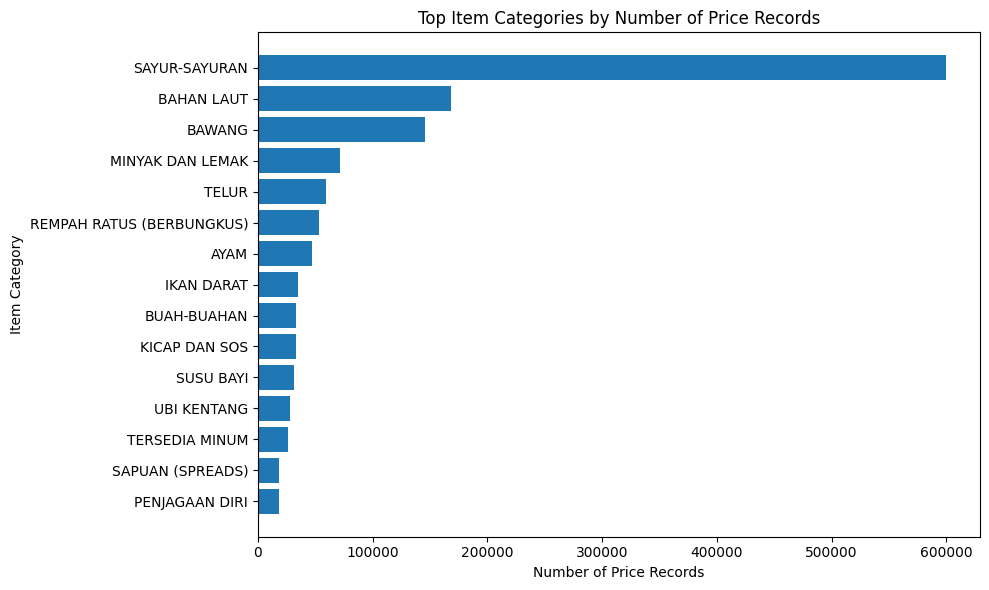

In [15]:
top_categories = category_summary.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_categories["item_category"], top_categories["num_records"])
plt.xlabel("Number of Price Records")
plt.ylabel("Item Category")
plt.title("Top Item Categories by Number of Price Records")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This plot tells us the dataset is heavily concentrated in fresh food, especially vegetables, seafood, onions, oils, eggs, and chicken.

This plot is useful because it shows:

SAYUR-SAYURAN = most prominent category by far
BAHAN LAUT = second biggest
BAWANG = third
MINYAK DAN LEMAK, TELUR, AYAM = also important daily staples

Item browsing table

In [16]:
items_df = (
    df_clean[["item_code", "item", "unit", "item_group", "item_category"]]
    .drop_duplicates()
    .sort_values(["item_category", "item"])
)

print("Unique items:", items_df.shape[0])
items_df.head(100)

Unique items: 339


,item_code,item,unit,item_group,item_category
0,1,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
53,2,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM
151048,1551,DADA AYAM (CHICKEN KEEL) (1KG),1kg,BARANGAN SEGAR,AYAM
151056,1804,KEPAK AYAM (CHICKEN WING) (1KG),1kg,BARANGAN SEGAR,AYAM
151047,1550,PAHA AYAM (CHICKEN DRUMSTICK),1kg,BARANGAN SEGAR,AYAM
151049,1552,THIGH AYAM,1kg,BARANGAN SEGAR,AYAM
151050,1553,WHOLE LEG AYAM,1kg,BARANGAN SEGAR,AYAM
151006,43,IKAN BAWAL HITAM (ANTARA 2 HINGGA 5 EKOR SEKIL...,1kg,BARANGAN SEGAR,BAHAN LAUT
573,1475,IKAN BAWAL PUTIH (ANTARA 2 HINGGA 5 EKOR SEKIL...,1kg,BARANGAN SEGAR,BAHAN LAUT
1,47,IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT


Define starter basket categories

In [17]:
starter_categories = [
    "AYAM",
    "TELUR",
    "BERAS",
    "MINYAK DAN LEMAK",
    "BAWANG",
    "SAYUR-SAYURAN",
    "BAHAN LAUT",
    "IKAN DARAT",
    "BUAH-BUAHAN"
]

basket_items = items_df[
    items_df["item_category"].isin(starter_categories)
].copy()

print("Starter basket unique items:", basket_items.shape[0])

basket_items[
    ["item_code", "item", "unit", "item_group", "item_category"]
].head(100)

Starter basket unique items: 140


,item_code,item,unit,item_group,item_category
0,1,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM
53,2,AYAM BERSIH - SUPER,1kg,BARANGAN SEGAR,AYAM
151048,1551,DADA AYAM (CHICKEN KEEL) (1KG),1kg,BARANGAN SEGAR,AYAM
151056,1804,KEPAK AYAM (CHICKEN WING) (1KG),1kg,BARANGAN SEGAR,AYAM
151047,1550,PAHA AYAM (CHICKEN DRUMSTICK),1kg,BARANGAN SEGAR,AYAM
151049,1552,THIGH AYAM,1kg,BARANGAN SEGAR,AYAM
151050,1553,WHOLE LEG AYAM,1kg,BARANGAN SEGAR,AYAM
151006,43,IKAN BAWAL HITAM (ANTARA 2 HINGGA 5 EKOR SEKIL...,1kg,BARANGAN SEGAR,BAHAN LAUT
573,1475,IKAN BAWAL PUTIH (ANTARA 2 HINGGA 5 EKOR SEKIL...,1kg,BARANGAN SEGAR,BAHAN LAUT
1,47,IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT


Filter the cleaned dataset to basket items

In [18]:
df_basket = df_clean[
    df_clean["item_code"].isin(basket_items["item_code"])
].copy()

print("Cleaned full dataset rows:", df_clean.shape[0])
print("Basket dataset rows:", df_basket.shape[0])

df_basket.head()

Cleaned full dataset rows: 1714308
Basket dataset rows: 1163747


,date,premise_code,item_code,price,month,item,unit,item_group,item_category,premise,address,premise_type,state,district
0,2026-04-01,2,1,10.8,2026-04,AYAM BERSIH - STANDARD,1kg,BARANGAN SEGAR,AYAM,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
1,2026-04-01,2,47,10.0,2026-04,IKAN CENCARU (ANTARA 4 HINGGA 6 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
2,2026-04-01,2,55,8.0,2026-04,IKAN KEMBUNG KECIL/PELALING (ANTARA 10 HINGGA ...,1kg,BARANGAN SEGAR,BAHAN LAUT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
3,2026-04-01,2,70,24.0,2026-04,IKAN SELAR PELATA (≤ 7 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,BAHAN LAUT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta
4,2026-04-01,2,88,10.0,2026-04,IKAN KELI (ANTARA 2 HINGGA 5 EKOR SEKILOGRAM),1kg,BARANGAN SEGAR,IKAN DARAT,PASAR BESAR IPOH,"JALAN LAKSAMANA,TAMAN JUBILEE,30300 IPOH, PERAK",Pasar Basah,Perak,Kinta


Check basket category coverage

In [19]:
basket_category_summary = (
    df_basket
    .groupby("item_category", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique"),
        num_premises=("premise_code", "nunique")
    )
    .sort_values("num_records", ascending=False)
)

basket_category_summary

,item_category,avg_price,median_price,num_records,num_items,num_premises
7,SAYUR-SAYURAN,8.024167,7.0,599325,31,1924
1,BAHAN LAUT,21.688029,18.0,167974,23,1368
2,BAWANG,5.726771,4.5,145649,10,2008
6,MINYAK DAN LEMAK,20.160968,16.3,71518,33,1858
8,TELUR,10.849698,10.8,59398,3,1814
0,AYAM,10.896713,10.0,46780,7,1522
5,IKAN DARAT,13.636916,13.0,34925,2,1096
4,BUAH-BUAHAN,9.594136,9.9,33526,14,1502
3,BERAS,31.643912,30.9,4652,17,993


Plot basket category coverage

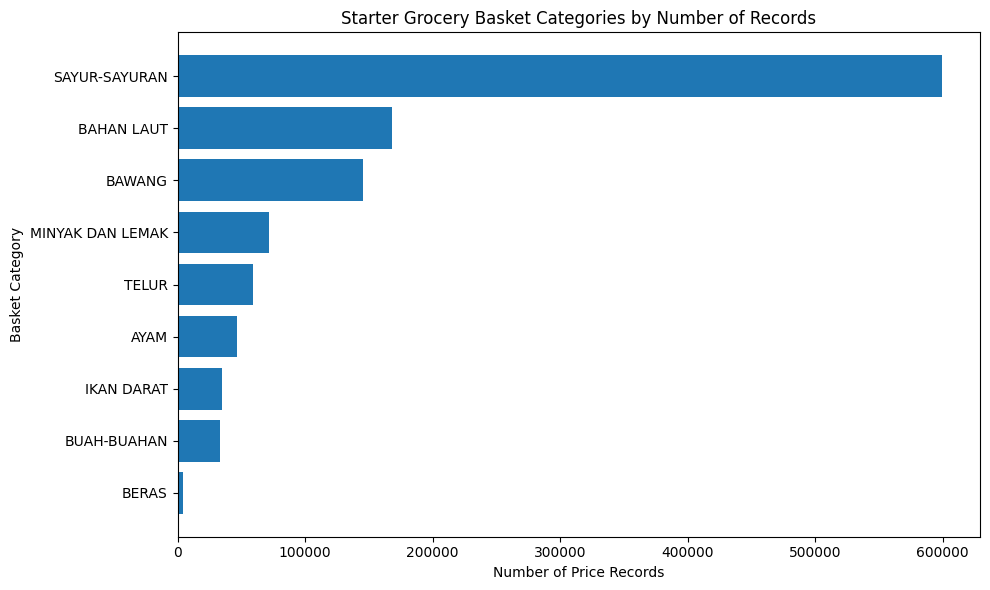

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(
    basket_category_summary["item_category"],
    basket_category_summary["num_records"]
)
plt.xlabel("Number of Price Records")
plt.ylabel("Basket Category")
plt.title("Starter Grocery Basket Categories by Number of Records")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

State-Level EDA

In [21]:
state_basket = (
    df_basket
    .groupby("state", as_index=False)
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique"),
        num_premises=("premise_code", "nunique")
    )
    .sort_values("avg_price", ascending=False)
)

state_basket

,state,avg_price,median_price,num_records,num_items,num_premises
15,W.P. Putrajaya,12.413051,9.99,18203,117,28
10,Sarawak,12.397588,9.90,103309,113,229
13,W.P. Kuala Lumpur,11.732106,9.45,137029,128,181
11,Selangor,11.318594,9.00,96325,121,134
9,Sabah,11.295836,8.80,62836,118,179
8,Pulau Pinang,10.924746,9.00,88298,122,148
3,Melaka,10.767375,8.59,29871,115,53
4,Negeri Sembilan,10.761836,8.50,41851,113,64
6,Perak,10.724220,8.99,119605,122,192
7,Perlis,10.692116,8.99,16448,100,37


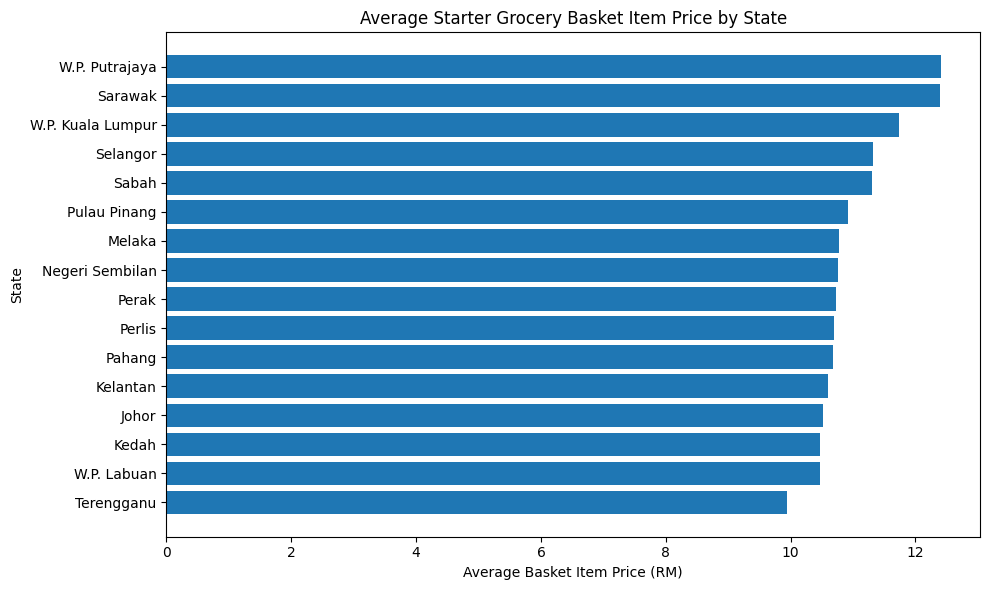

In [22]:
plt.figure(figsize=(10, 6))
plt.barh(state_basket["state"], state_basket["avg_price"])
plt.xlabel("Average Basket Item Price (RM)")
plt.ylabel("State")
plt.title("Average Starter Grocery Basket Item Price by State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The state-level comparison shows that W.P. Putrajaya, Sarawak, W.P. Kuala Lumpur, Selangor, and Sabah had the highest average prices for the starter grocery basket in April 2026. However, this simple average should be interpreted carefully because it may be affected by differences in item mix across states. For example, a state with more seafood records may appear more expensive than a state with more vegetable records. A later version of the project should use a standardized basket or category-level weights to make comparisons fairer.

Create monthly basket dataset

In [23]:
monthly_basket = (
    df_basket
    .groupby(["month", "state", "premise_type"], as_index=False)
    .agg(
        basket_price=("price", "mean"),
        median_basket_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique"),
        num_premises=("premise_code", "nunique")
    )
)

monthly_basket.sort_values("basket_price", ascending=False).head(20)

,month,state,premise_type,basket_price,median_basket_price,num_records,num_items,num_premises
50,2026-04,Sabah,Kedai Runcit,15.304978,13.30,2031,71,36
62,2026-04,Selangor,Kedai Runcit,14.967699,12.00,226,55,3
56,2026-04,Sarawak,Kedai Runcit,14.778675,12.50,3185,74,52
85,2026-04,W.P. Putrajaya,Pasar Basah,14.728788,12.00,1122,50,1
84,2026-04,W.P. Putrajaya,Pasar Basah,13.799790,12.00,1049,52,1
47,2026-04,Pulau Pinang,Pasar Mini,13.562675,10.90,7562,91,58
53,2026-04,Sabah,Pasar Mini,13.486074,11.50,3281,95,36
76,2026-04,W.P. Kuala Lumpur,Pasar Mini,13.421772,11.59,3809,99,34
31,2026-04,Pahang,Pasar Mini,13.209105,10.99,7136,95,68
86,2026-04,W.P. Putrajaya,Pasar Mini,13.068644,10.50,3524,97,10


The cleaned dataset is concentrated in everyday grocery categories. Vegetables have the largest number of price records, followed by seafood, onions, oils, eggs, and chicken. This confirms that PriceCatcher is suitable for constructing a food-focused cost-of-living basket. For the starter basket, I selected essential food categories such as chicken, eggs, rice, oils, onions, vegetables, seafood, freshwater fish, and fruit.

Clean text columns

In [24]:
# Clean text columns to avoid duplicate-looking categories caused by spaces/casing

text_cols = [
    "item",
    "unit",
    "item_group",
    "item_category",
    "premise",
    "premise_type",
    "state",
    "district"
]

for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

# Recreate basket dataset after text cleaning
df_basket = df_clean[
    df_clean["item_code"].isin(basket_items["item_code"])
].copy()

print("Basket rows:", df_basket.shape)

Basket rows: (1163747, 14)


In [25]:
df_basket["premise_type"].value_counts(dropna=False)

premise_type
Pasar Raya / Supermarket    636987
Pasar Basah                 276669
Hypermarket                 145083
Pasar Mini                   78504
Kedai Runcit                 26504
Name: count, dtype: int64

Recreate the monthly basket table

In [26]:
monthly_basket = (
    df_basket
    .groupby(["month", "state", "premise_type"], as_index=False)
    .agg(
        basket_price=("price", "mean"),
        median_basket_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique"),
        num_premises=("premise_code", "nunique")
    )
    .sort_values("basket_price", ascending=False)
)

monthly_basket.head(20)

,month,state,premise_type,basket_price,median_basket_price,num_records,num_items,num_premises
46,2026-04,Sabah,Kedai Runcit,15.304978,13.30,2031,71,36
56,2026-04,Selangor,Kedai Runcit,14.967699,12.00,226,55,3
51,2026-04,Sarawak,Kedai Runcit,14.778675,12.50,3185,74,52
76,2026-04,W.P. Putrajaya,Pasar Basah,14.279908,12.00,2171,57,2
43,2026-04,Pulau Pinang,Pasar Mini,13.562675,10.90,7562,91,58
48,2026-04,Sabah,Pasar Mini,13.486074,11.50,3281,95,36
68,2026-04,W.P. Kuala Lumpur,Pasar Mini,13.421772,11.59,3809,99,34
28,2026-04,Pahang,Pasar Mini,13.209105,10.99,7136,95,68
77,2026-04,W.P. Putrajaya,Pasar Mini,13.068644,10.50,3524,97,10
58,2026-04,Selangor,Pasar Mini,13.040094,10.80,5408,90,51


Category level state comparison

In [27]:
state_category_prices = (
    df_basket
    .groupby(["state", "item_category"], as_index=False)
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique")
    )
)

state_category_prices.head()

,state,item_category,avg_price,median_price,num_records,num_items
0,Johor,AYAM,10.275638,8.69,5468,7
1,Johor,BAHAN LAUT,20.517079,16.00,21057,22
2,Johor,BAWANG,5.457487,4.00,15975,10
3,Johor,BERAS,32.452500,32.90,336,6
4,Johor,BUAH-BUAHAN,9.659461,9.99,3450,7


Pivot table

In [28]:
state_category_pivot = state_category_prices.pivot_table(
    index="state",
    columns="item_category",
    values="avg_price"
)

state_category_pivot

item_category,AYAM,BAHAN LAUT,BAWANG,BERAS,BUAH-BUAHAN,IKAN DARAT,MINYAK DAN LEMAK,SAYUR-SAYURAN,TELUR
state,,,,,,,,,
Johor,10.275638,20.517079,5.457487,32.452500,9.659461,13.190889,19.967179,7.397524,10.066074
Kedah,10.086999,21.773443,5.715547,33.505032,10.456579,12.662015,20.017519,7.320312,10.169175
Kelantan,10.005115,21.573467,4.590312,33.358037,8.892039,12.276608,19.368734,7.644905,10.747053
Melaka,10.401554,21.223447,5.911056,35.400750,8.872226,12.188991,18.779849,7.380299,10.224141
Negeri Sembilan,10.084210,21.897745,5.806629,33.777766,9.936551,12.168787,19.593383,7.367581,10.239071
Pahang,10.075347,21.791779,5.224214,31.840113,9.892946,14.113777,20.264404,7.295310,10.266500
Perak,10.427887,21.154385,5.714628,32.765076,8.545071,12.423821,19.597086,7.430379,10.054426
Perlis,10.607394,22.729394,5.941818,31.801869,11.620355,12.300921,19.776898,8.620346,10.094541
Pulau Pinang,11.190828,22.604736,6.456538,31.654103,9.619662,13.067191,19.724509,7.640237,10.994967


Better state ranking: average category price

In [29]:
state_standardized = (
    state_category_prices
    .groupby("state", as_index=False)
    .agg(
        standardized_basket_price=("avg_price", "mean"),
        categories_available=("item_category", "nunique"),
        total_records=("num_records", "sum")
    )
    .sort_values("standardized_basket_price", ascending=False)
)

state_standardized

,state,standardized_basket_price,categories_available,total_records
10,Sarawak,15.844194,9,103309
15,W.P. Putrajaya,15.488826,9,18203
13,W.P. Kuala Lumpur,15.310292,9,137029
9,Sabah,15.271524,9,62836
14,W.P. Labuan,15.220874,9,5964
11,Selangor,14.941421,9,96325
7,Perlis,14.832615,9,16448
8,Pulau Pinang,14.772530,9,88298
12,Terengganu,14.738898,9,60029
1,Kedah,14.634069,9,67351


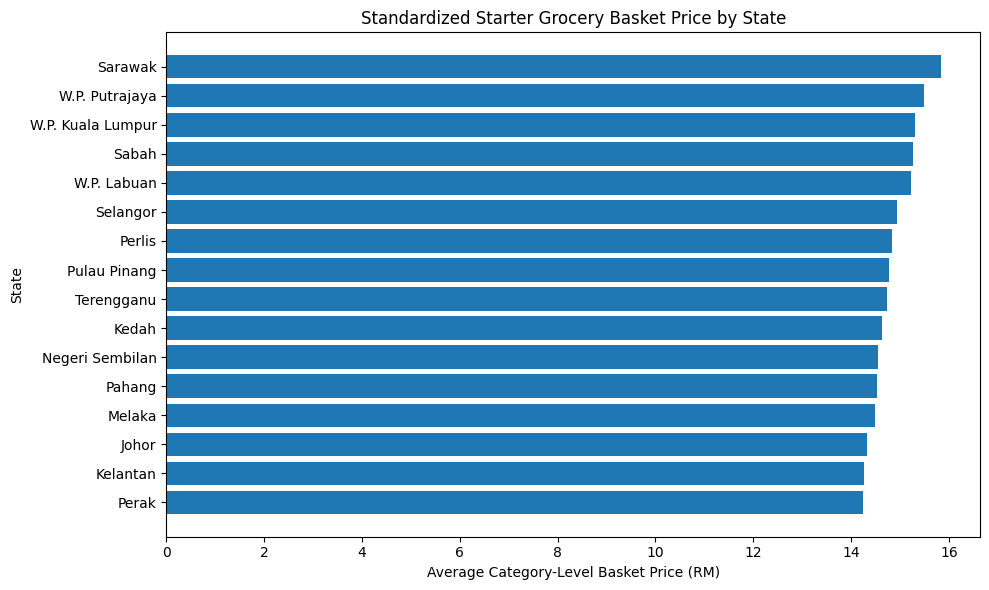

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(state_standardized["state"], state_standardized["standardized_basket_price"])
plt.xlabel("Average Category-Level Basket Price (RM)")
plt.ylabel("State")
plt.title("Standardized Starter Grocery Basket Price by State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Clean text labels

In [31]:
text_cols = [
    "item",
    "unit",
    "item_group",
    "item_category",
    "premise",
    "premise_type",
    "state",
    "district"
]

for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

Standardized basket comparison

In [32]:
state_category_prices = (
    df_basket
    .groupby(["state", "item_category"], as_index=False)
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique")
    )
)

In [33]:
state_standardized = (
    state_category_prices
    .groupby("state", as_index=False)
    .agg(
        standardized_basket_price=("avg_price", "mean"),
        categories_available=("item_category", "nunique"),
        total_records=("num_records", "sum")
    )
    .sort_values("standardized_basket_price", ascending=False)
)

state_standardized

,state,standardized_basket_price,categories_available,total_records
10,Sarawak,15.844194,9,103309
15,W.P. Putrajaya,15.488826,9,18203
13,W.P. Kuala Lumpur,15.310292,9,137029
9,Sabah,15.271524,9,62836
14,W.P. Labuan,15.220874,9,5964
11,Selangor,14.941421,9,96325
7,Perlis,14.832615,9,16448
8,Pulau Pinang,14.772530,9,88298
12,Terengganu,14.738898,9,60029
1,Kedah,14.634069,9,67351


Expand from one month to 6 months

In [34]:
months = [
    "2025-11",
    "2025-12",
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04"
]

Loop through URLs

In [35]:
price_frames = []

for month in months:
    url = f"https://storage.data.gov.my/pricecatcher/pricecatcher_{month}.parquet"
    temp = pd.read_parquet(url)
    price_frames.append(temp)
    print(f"Loaded {month}: {temp.shape}")

price_all = pd.concat(price_frames, ignore_index=True)

Loaded 2025-11: (1783107, 4)
Loaded 2025-12: (1782274, 4)
Loaded 2026-01: (1976483, 4)
Loaded 2026-02: (1369552, 4)
Loaded 2026-03: (1547695, 4)
Loaded 2026-04: (1745608, 4)


Monthly modeling dataset

In [36]:
monthly_basket = (
    df_basket
    .groupby(["month", "state", "premise_type"], as_index=False)
    .agg(
        basket_price=("price", "mean"),
        median_basket_price=("price", "median"),
        num_records=("price", "count"),
        num_items=("item_code", "nunique"),
        num_premises=("premise_code", "nunique")
    )
)